In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib import colors
from matplotlib.gridspec import GridSpec

from aopy.visualization import annotate_spatial_map_channels, place_Opto32_subplots, plot_angles
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials
from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site, calc_connectivity_map_coh, prepare_erp
from aopy.analysis import calc_itpc
from aopy.analysis.latency import detect_itpc_response
from aopy.analysis import calc_stat_over_dist_from_pos, calc_stat_over_angle_from_pos
from aopy.analysis import calc_fdrc_ranktest, calc_tfr_mean_fdrc_ranktest, calc_tfr_mean
from aopy.visualization import plot_annotated_spatial_drive_map_stim, plot_annotated_stim_drive_data
from aopy.visualization import overlay_sulci_on_spatial_map, plot_xy_scalebar, plot_tf_map_grid, plot_spatial_drive_maps
from aopy.analysis import calc_spatial_data_correlation, calc_spatial_tf_data_correlation

data_dir = '/media/moor-data/raw'
preproc_dir = '/data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v250623'
alpha = 0.01

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', style='ticks', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
from connectivity_analysis import *
from connectivity_plotting import *

In [4]:
aopy.utils.memory.set_memory_limit_gb(500)

## Load data

In [5]:
# Precomputed connectivity from all sites
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

## Eyes open or closed

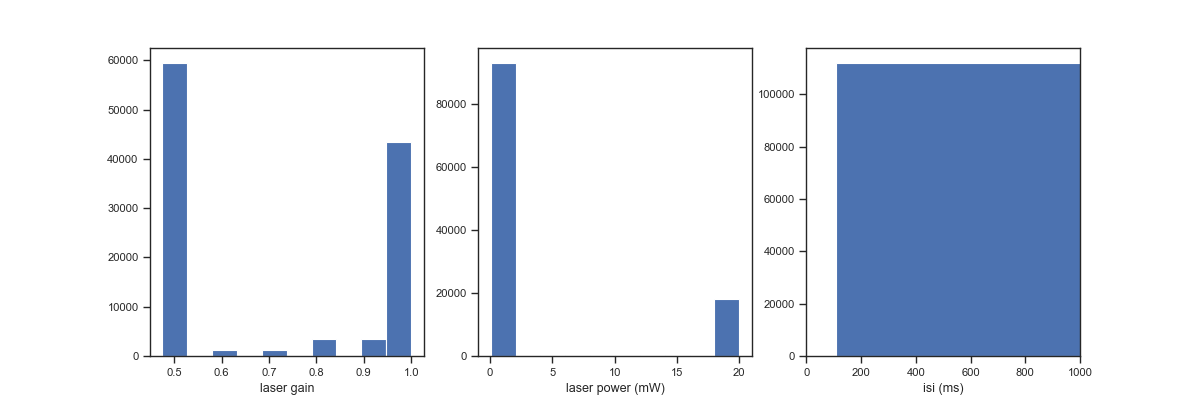

In [6]:
b_long_df = load_df(postproc_dir, 'beignet', 'rest_long', version)
trial_filter = filter_stim_trials(b_long_df, gain_range=[0.45, 0.55], min_isi=0.01)
b_long_df = b_long_df[trial_filter].reset_index()

In [7]:
stim_site = 11
subject = 'beignet'
subject_data = b_long_df
theta = 0

# Subselect trials 
df = subject_data[(subject_data['stimulation_site'].astype(int) == stim_site)].reset_index().tail(18000).head(8000)
print(f"{len(df)} total trials for site {stim_site}")

# Get eye masks
eyes_open_trials, eyes_closed_trials = get_open_closed_mask(preproc_dir, df)

df_closed = df.iloc[eyes_closed_trials].reset_index(drop=True)
df_closed['condition'] = 'closed'
df_open = df.iloc[eyes_open_trials].reset_index(drop=True)
df_open['condition'] = 'open'
df = pd.concat([df_open, df_closed]).reset_index(drop=True)
df, num = make_equal_sizes(df)

max_erp_open = calc_opto_resp(df[df['condition'] == 'open'].reset_index(drop=True))
max_erp_closed = calc_opto_resp(df[df['condition'] == 'closed'].reset_index(drop=True))

8000 total trials for site 11
2441 open, 1704 closed (8000 total)
Before: 2441 trials for open, 1704 trials for closed
After: 1704 trials for closed, 1704 trials for open


/home/aolab/projects/ECoG_opto_connectivity/connectivity_analysis.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=seed))


In [8]:
# # Forgot to make one shuffled distribution
# shuff_labels = df['condition'].to_numpy()
# np.random.shuffle(shuff_labels)
# stat = get_connectivity_statistic(stim_site, 'slic')
# # shuff1, shuff2, _ = compare_dists_bootstrap(
# #     df, shuff_labels, n_trials=200, n_bootstraps=50, 
# #     statistic=stat, parallel=True
# # )
# observed_dists, _, _, shuff_dprime = compare_conditions_bootstrap_spatial_corr(
#     df, elec_pos, shuff_labels, n_trials=200, n_bootstraps=50,
#     statistics=stat, parallel=True
# )
# shuff1 = observed_dists[0]
# shuff2 = observed_dists[1]

In [9]:
# Load data
elec_pos, acq_ch, elecs = aopy.data.load_chmap()

filename = f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl'
filepath = os.path.join(postproc_dir, filename)
site_data = aopy.data.pkl_read(f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                       postproc_dir)

mean12 = np.concatenate([site_data['mean1'], site_data['mean2']])
clim = (np.min(mean12),np.max(mean12))
diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], site_data['shuff_dprime'])

(3408,)


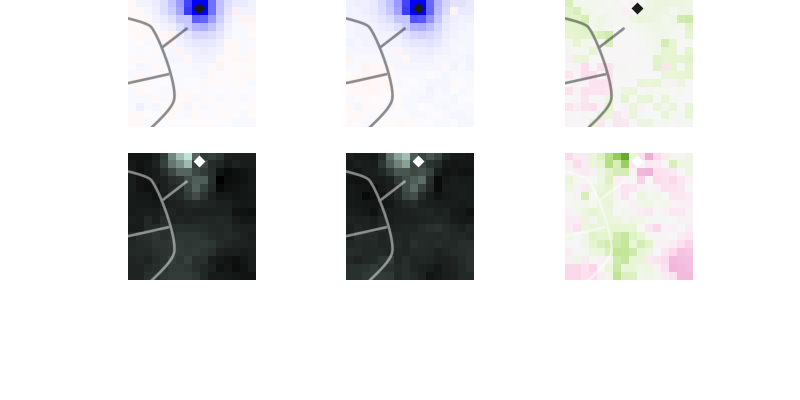

In [10]:
df_sort = df.sort_values(['te_id', 'trial_time'])
c = df_sort['condition'].to_numpy()
print(c.shape)
plt.figure(figsize=(4,2), dpi=200)
plt.subplots_adjust(bottom=0.3, top=1, hspace=0.2)

plt.subplot(2,3,1)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    max_erp_open, stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap='bwr', colorbar=False, color='k')
im.set_clim(-3,3)
plt.axis('off')

plt.subplot(2,3,2)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    max_erp_closed, stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap='bwr', colorbar=False, color='k')
im.set_clim(-3,3)
plt.axis('off')

plt.subplot(2,3,3)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    max_erp_open-max_erp_closed, stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap='PiYG', colorbar=False, color='k')
im.set_clim(-1,1)
plt.axis('off')

plt.subplot(2,3,4)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    site_data['mean2'], stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap=cmap_slic, colorbar=False)
im.set_clim(*clim)
plt.axis('off')

plt.subplot(2,3,5)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    site_data['mean1'], stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap=cmap_slic, colorbar=False)
im.set_clim(*clim)
plt.axis('off')

plt.subplot(2,3,6)
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    site_data['mean2']-site_data['mean1'], stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap='PiYG', colorbar=False)
im.set_clim(-0.05, 0.05)
plt.axis('off')

filename = 'state_comparison_example_maps.svg'
aopy.visualization.savefig(fig_dir, filename)

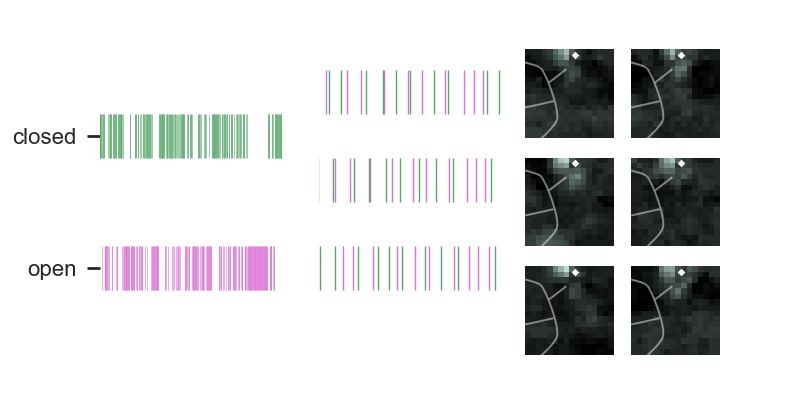

In [11]:
plt.figure(figsize=(4,2), dpi=200)
plt.subplot(1,3,1)
open_trials = np.where(c == 'open')[0]
closed_trials = np.where(c == 'closed')[0]
plt.eventplot(open_trials, lineoffsets=0, linewidths=0.2, color='orchid')
plt.eventplot(closed_trials, lineoffsets=3, linewidths=0.2, color='g')
plt.margins(y=0.5)
plt.yticks([0,3], labels=['open', 'closed'])
plt.xticks([])
plt.xlim(200,600)
plt.ylim(-2,5)
sns.despine(left=True,bottom=True)

plt.subplot(1,3,2)
for idx in range(3):
    plt.eventplot(open_trials[idx*15::20], lineoffsets=idx*2, linewidths=0.5, color='orchid')
    plt.eventplot(closed_trials[idx*15::20], lineoffsets=idx*2, linewidths=0.5, color='g')
plt.margins(y=0.5)
plt.yticks([])
plt.xticks([])
plt.xlim(200,600)
plt.ylim(-2,5)
sns.despine(left=True,bottom=True)

for idx in range(3):
    plt.subplot(3,6,5+idx*6)
    im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
        site_data['dist2'][idx][0], stim_site, subject, 'lm1', theta, 
        elec_data=True, cmap=cmap_slic, colorbar=False)
    im.set_clim(*clim)
    plt.axis('off')

    plt.subplot(3,6,6+idx*6)
    im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
        site_data['dist1'][idx][0], stim_site, subject, 'lm1', theta, 
        elec_data=True, cmap=cmap_slic, colorbar=False)
    im.set_clim(*clim)
    plt.axis('off')

filename = 'state_comparison_methods.svg'
aopy.visualization.savefig(fig_dir, filename)

In [12]:
print(f"site {stim_site} has {len(site_data['shuff_dprime'])} shuffles")
print(f"each shuffle is {len(site_data['dist1'])} bootstraps * {len(site_data['dist1'][0])} groups")

site 11 has 50 shuffles
each shuffle is 50 bootstraps * 8 groups


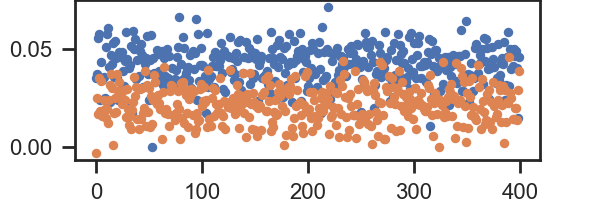

In [13]:
plt.figure(figsize=(3,1), dpi=200)
plt.subplots_adjust(bottom=0.2, top=1, hspace=0.5, wspace=0.5)

# histogram of example channel
sorted_chs = np.flip(np.argsort(site_data['observed_dprime']))
biggest_ch = sorted_chs[0]

dist1c = [float(c[biggest_ch]) for c in np.concatenate(site_data['dist1'])]
dist2c = [float(c[biggest_ch]) for c in np.concatenate(site_data['dist2'])]
dist_shuff1 = [float(c[biggest_ch]) for c in np.concatenate(site_data['shuff_dists1'][0])]
dist_shuff2 = [float(c[biggest_ch]) for c in np.concatenate(site_data['shuff_dists2'][0])]

plt.plot(dist1c, '.')
plt.plot(dist2c, '.')
# plt.plot(dist_shuff1, 'o')
# plt.plot(dist_shuff2, 'o')

d-prime: 2.0862581197244188
d-prime shuff: 0.04378819858355806


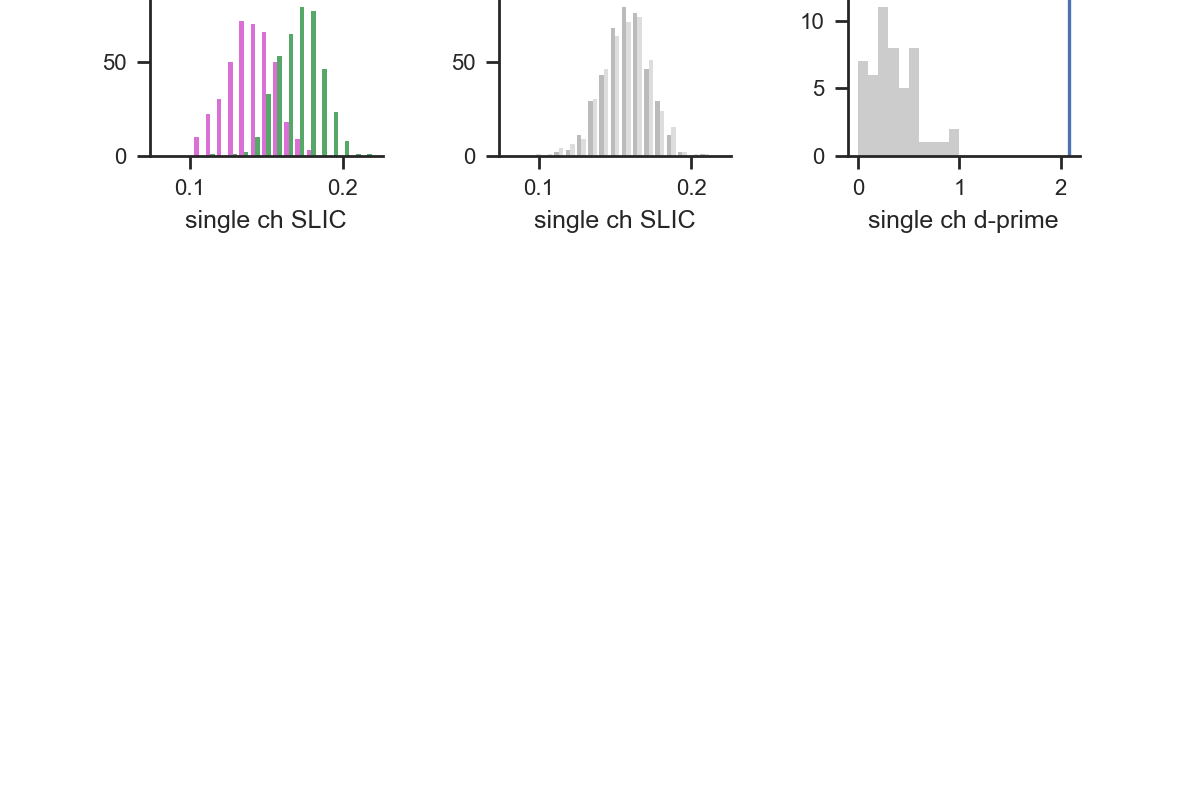

In [14]:
plt.figure(figsize=(6,4), dpi=200)
plt.subplots_adjust(bottom=0.3, top=1, hspace=0.3, wspace=0.5)

stim_site = 11
subject = 'beignet'
theta = 0
site_data = aopy.data.pkl_read(f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                       postproc_dir)

# histogram of example channel
sorted_chs = np.flip(np.argsort(site_data['observed_dprime']))
example_ch = 32

dist1c = [float(c[example_ch]) for c in np.concatenate(site_data['dist1'])]
dist2c = [float(c[example_ch]) for c in np.concatenate(site_data['dist2'])]
dist_shuff1 = [float(c[example_ch]) for c in np.concatenate(site_data['shuff_dists1'][0])]
dist_shuff2 = [float(c[example_ch]) for c in np.concatenate(site_data['shuff_dists2'][0])]

bins = np.linspace(0.08, 0.22, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

# Hist counts
counts1, _ = np.histogram(dist1c, bins=bins)
counts2, _ = np.histogram(dist2c, bins=bins)
counts_shuff1, _ = np.histogram(dist_shuff1, bins=bins)
counts_shuff2, _ = np.histogram(dist_shuff2, bins=bins)

# Bar width and offsets
bar_width = bin_width * 0.4

# Plot bars manually
plt.subplot(3,3,1)
plt.bar(bin_centers - bar_width/2, counts1, width=bar_width, edgecolor='none', color='orchid')
plt.bar(bin_centers + bar_width/2, counts2, width=bar_width, edgecolor='none', color='g')
sns.despine()
plt.xlabel('single ch SLIC')
print('d-prime:', site_data['observed_dprime'][example_ch])
print('d-prime shuff:', site_data['shuff_dprime'][0][example_ch])

plt.subplot(3,3,2)
plt.bar(bin_centers - bar_width/2, counts_shuff1, width=bar_width, edgecolor='none', color='#bbbbbb')
plt.bar(bin_centers + bar_width/2, counts_shuff2, width=bar_width, edgecolor='none', color='#dddddd')
sns.despine()
plt.xlabel('single ch SLIC')

# d-prime example
plt.subplot(3,3,3)
shuffled_dprime = [s[example_ch] for s in site_data['shuff_dprime']]
bins = np.arange(0, 2, 0.1)
plt.hist(shuffled_dprime, bins, edgecolor='none', facecolor='#cccccc')
plt.axvline(site_data['observed_dprime'][example_ch], color='b')
plt.xlabel('single ch d-prime')
sns.despine()


# Coefficients
# plt.subplot(3,2,6)
# groups = ['open', 'closed', 'across']
# datas = [coeff[1], coeff[0], coeff[2]]
# df_plot = None
# for group, data in zip(groups, datas):
#     df_plot = pd.concat([df_plot, pd.DataFrame({'group': group, 'correlation': data})])

# sns.violinplot(data=df_plot, x='group', y='correlation')
# annotator = Annotator(plt.gca(), pairs=[('open', 'closed'), ('open', 'across')], data=df_plot, x="group", y="correlation")
# annotator.configure(test=None, loc="outside")
# annotator.set_pvalues(p_values)
# annotator.annotate()

# plt.ylim(0,1)
# sns.despine()

filename = 'state_comparison_summary.svg'
aopy.visualization.savefig(fig_dir, filename)

0.0
beignet sites: [11, 7, 15]
0
0 3
0 4
affi sites: [14, 20]
1 3
1 4


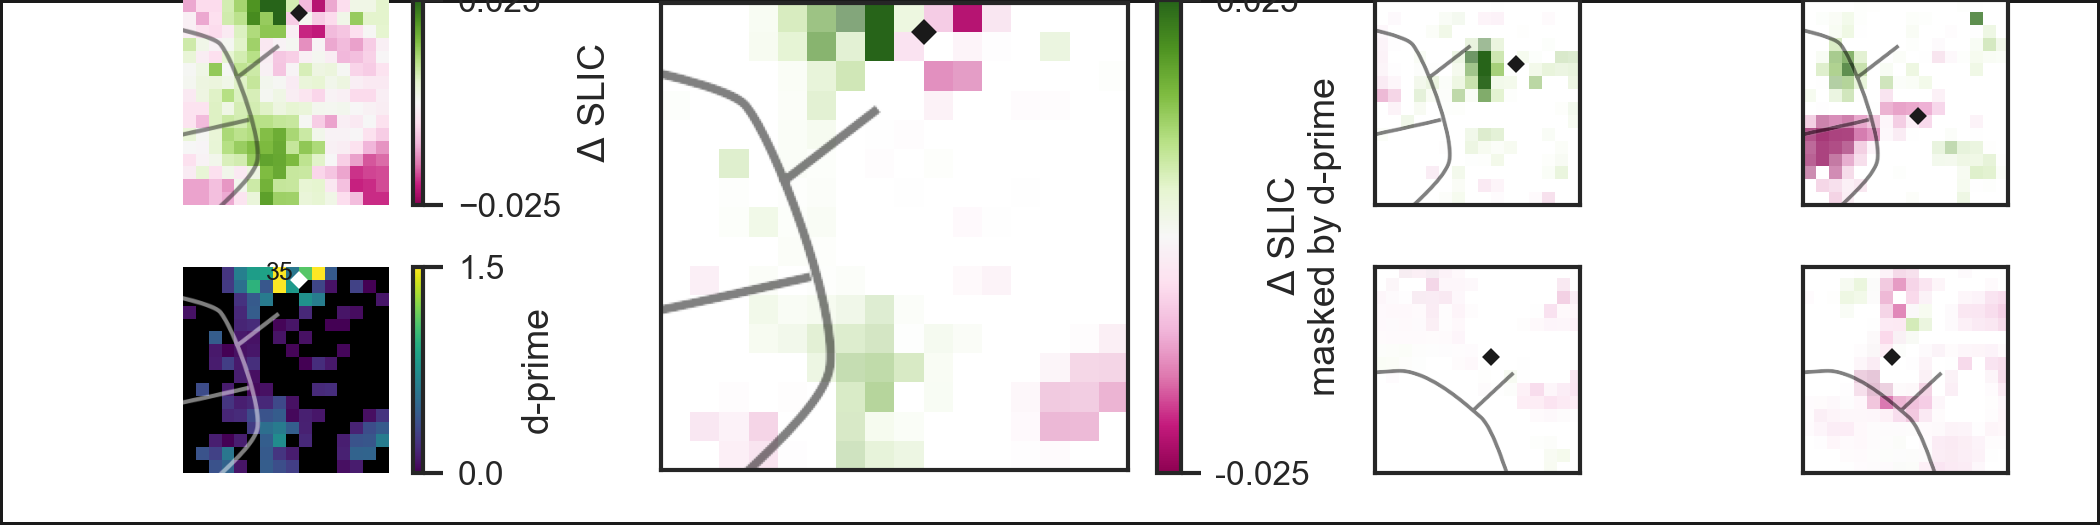

In [36]:
fig = plt.figure(figsize=(7, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.25, 0.05, 0.3, 0.2, 0.2]
grid2 = GridSpec(2, 5, width_ratios=wr, wspace=0.1, hspace=0.3)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

stim_site = 11
subject = 'beignet'
theta = 0
site_data = aopy.data.pkl_read(f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                       postproc_dir)

#d-prime summary
ax = fig.add_subplot(grid2[0,0])
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    site_data['mean2']-site_data['mean1'], stim_site, subject, 'lm1', theta, 
    elec_data=True, cmap='PiYG', color='k', colorbar=True, markersize=0.7)
im.set_clim(-0.025, 0.025)
cbar.set_ticks([-0.025, 0.025])
cbar.set_label('$\\Delta$ SLIC')
plt.axis('off')

ax = fig.add_subplot(grid2[1,0])
shuffled_dprime = np.tile(np.concatenate(site_data['shuff_dprime']), (240,1)).T
diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], shuffled_dprime, alpha=alpha)
diff[p > alpha] = np.nan
im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
    diff, stim_site, subject, 'lm1', theta, interp=False,
    elec_data=True, cmap='viridis', colorbar=True, markersize=0.7)
im.set_clim(0,1.5)
cbar.set_ticks([0,1.5])
cbar.set_label('d-prime')
aopy.visualization.annotate_spatial_map_channels(acq_ch=[acq_ch[example_ch]])
plt.axis('off')

print(p[example_ch])

idx = 0
for subject in ['beignet', 'affi']:
    
    if subject == 'affi':
        theta = 90
        stim_sites = [14, 20]

    else:
        theta = 0
        stim_sites = [11, 7, 15]

    
    print(f"{subject} sites: {stim_sites}")
    
    for stim_site in stim_sites:
        
        # Check if we've computed this site
        filename = f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl'
        filepath = os.path.join(postproc_dir, filename)
        if not os.path.exists(filepath):
            print(f'no file yet for site {stim_site}')
            continue

        # Load data
        site_data = aopy.data.pkl_read(f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                               postproc_dir)
        
        shuffled_dprime = np.tile(np.concatenate(site_data['shuff_dprime']), (240,1)).T
        diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], shuffled_dprime, alpha=alpha)
        diff[p > alpha] = np.nan

        if idx == 0:
            print(idx)
            ax = fig.add_subplot(grid2[:,2])
        else:
            print((idx-1)//2,3+(idx-1)%2)
            ax = fig.add_subplot(grid2[(idx-1)//2,3+(idx-1)%2])
        elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)
        alpha_map = aopy.visualization.get_data_map(diff, elec_pos[:,0], elec_pos[:,1])
        alpha_map[alpha_map < 0] = 0
        alpha_map/= 1.5
        alpha_map[alpha_map > 1.] = 1.
        im = aopy.visualization.plot_spatial_drive_map(site_data['mean2']-site_data['mean1'],
                                                  alpha_map=alpha_map,
                                                  elec_data=True, cmap='PiYG', 
                                                  clim=(-0.025,0.025))
        # print(ax.get_xaxis_transform().get_matrix()[0,0])
        if idx == 0:
            cbar = plt.colorbar(im)
            cbar.set_ticks([0,1])
            cbar.set_ticklabels([-0.025, 0.025])
            cbar.set_label('$\\Delta$ SLIC\nmasked by d-prime', labelpad=-10)
        aopy.visualization.annotate_spatial_map_channels(acq_ch=[stim_site], drive_type='Opto32', 
                                                         annotation_style='marker', marker='D', 
                                                         markersize=1.0 if idx==0 else 0.7, ax=ax)
        aopy.visualization.overlay_sulci_on_spatial_map(subject, 'lm1', 'ECoG244', theta)
        
        plt.gca().set(xlabel='', ylabel='', xticks=[], yticks=[])

        idx += 1

filename = 'state_comparison_all.svg'
aopy.visualization.savefig(fig_dir, filename)

beignet sites: [7, 11, 15]
affi sites: [14, 20]


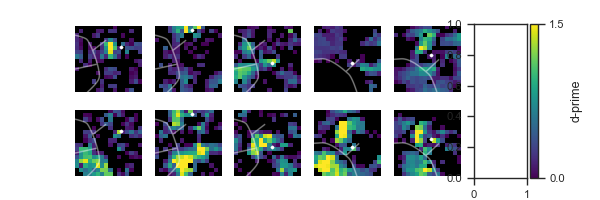

In [16]:
# Granger comparison
plt.figure(figsize=(6,2))
idx = 1
slic_dp_count = []
gc_dp_count = []
slic_dp_all = []
gc_dp_all = []
for subject in ['beignet', 'affi']:
    
    if subject == 'affi':
        theta = 90
        stim_sites = [14, 20]

    else:
        theta = 0
        stim_sites = [7, 11, 15]

    
    print(f"{subject} sites: {stim_sites}")
    
    for stim_site in stim_sites:
        
        # Check if we've computed this site
        filename = f'{subject}_gc_connectivity_eyes_state_site_{stim_site}_{version}.pkl'
        filepath = os.path.join(postproc_dir, filename)
        if not os.path.exists(filepath):
            print(f'no file yet for site {stim_site}')
            continue

        # Load and plot SLIC data
        site_data = aopy.data.pkl_read(f'{subject}_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                               postproc_dir)
        
        shuffled_dprime = np.tile(np.concatenate(site_data['shuff_dprime']), (240,1)).T
        diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], shuffled_dprime, alpha=alpha)
        diff[p > alpha] = np.nan
        slic_dp_all.append(site_data['observed_dprime'])
        slic_dp_count.append(np.count_nonzero(~np.isnan(diff)))
        
        plt.subplot(2,6,idx)
        im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
            diff, stim_site, subject, 'lm1', theta, interp=False,
            elec_data=True, cmap='viridis', colorbar=False)
        im.set_clim(0,1.5)
        plt.axis('off')
        
        # Load and plot GC data
        site_data = aopy.data.pkl_read(f'{subject}_gc_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                               postproc_dir)

        shuffled_dprime = np.tile(np.concatenate(site_data['shuff_dprime']), (240,1)).T
        diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], shuffled_dprime, alpha=alpha)
        diff[p > alpha] = np.nan
        gc_dp_all.append(site_data['observed_dprime'])
        gc_dp_count.append(np.count_nonzero(~np.isnan(diff)))
        
        plt.subplot(2,6,idx+6)
        im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
            diff, stim_site, subject, 'lm1', theta, interp=False,
            elec_data=True, cmap='viridis', colorbar=False)
        im.set_clim(0,1.5)
        plt.axis('off')
        
        idx += 1
        
plt.subplot(1,6,6)
cbar = plt.colorbar(im, ax=plt.gca())
cbar.set_ticks([0, 1.5])
cbar.set_label('d-prime')

filename = 'state_comparison_all_gc.svg'
aopy.visualization.savefig(fig_dir, filename)

(2, 1200)
(2, 5)


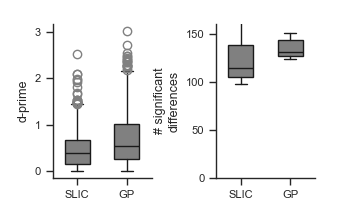

In [17]:
# Box plot comparing mean difference
plt.figure(figsize=(3.5,2))
plt.subplots_adjust(left=0.15, wspace=0.65)
plt.subplot(1,2,1)
data = np.array([slic_dp_all, gc_dp_all]).reshape(2,-1)
print(data.shape)
aopy.visualization.plot_boxplots([*data], ['SLIC', 'GP'], trendline=False)
plt.ylabel('d-prime')
sns.despine()

plt.subplot(1,2,2)
data = np.array([slic_dp_count, gc_dp_count])
print(data.shape)
aopy.visualization.plot_boxplots([*data], ['SLIC', 'GP'], trendline=False)
plt.ylim(0,160)
plt.ylabel('# significant\ndifferences')
sns.despine()

filename = 'state_comparison_all_summary.svg'
aopy.visualization.savefig(fig_dir, filename)

beignet sites: [7, 11, 15]
7 50
11 50
15 50
affi sites: [14, 20]
14 50
20 50


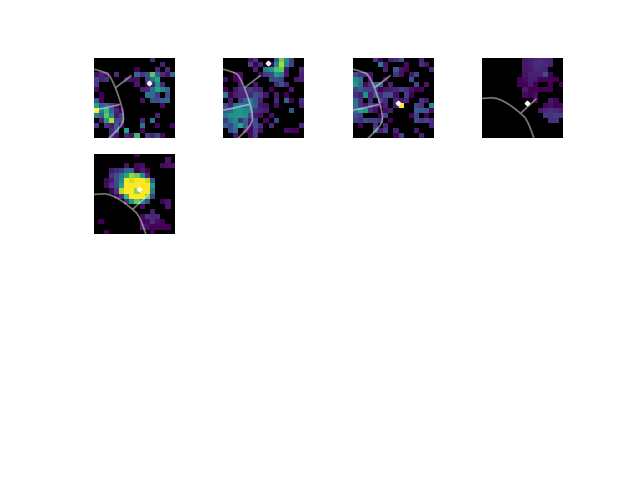

In [18]:
# Broadband comparison
idx = 1
for subject in ['beignet', 'affi']:
    
    if subject == 'affi':
        theta = 90
        stim_sites = [14, 20]

    else:
        theta = 0
        stim_sites = [7, 11, 15]

    
    print(f"{subject} sites: {stim_sites}")
    
    for stim_site in stim_sites:
        
        # Check if we've computed this site
        filename = f'{subject}_bb_connectivity_eyes_state_site_{stim_site}_{version}.pkl'
        filepath = os.path.join(postproc_dir, filename)
        if not os.path.exists(filepath):
            print(f'no file yet for site {stim_site}')
            continue

        # Load data
        site_data = aopy.data.pkl_read(f'{subject}_bb_connectivity_eyes_state_site_{stim_site}_{version}.pkl',
                               postproc_dir)

        shuffled_dprime = np.tile(np.concatenate(site_data['shuff_dprime']), (240,1)).T
        diff, p = calc_fdrc_ranktest(site_data['observed_dprime'], shuffled_dprime, alpha=alpha)
        diff[p > alpha] = np.nan
        
        print(stim_site, len(site_data['shuff_dprime']))
        
        plt.subplot(4,4,idx)
        im, cbar = aopy.visualization.plot_annotated_spatial_drive_map_stim(
            diff, stim_site, subject, 'lm1', theta, interp=False,
            elec_data=True, cmap='viridis', colorbar=False)
        im.set_clim(0,1.5)
        plt.axis('off')
        
        idx += 1

filename = 'state_comparison_all_bb.svg'
aopy.visualization.savefig(fig_dir, filename)